In [2]:
import numpy as np
import csv
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
# Initialization

data_file = "1702564889817O-result.csv"
Zero_points_lambda = {"Gia_g":2.5E-9, "Gia_Gpg":4.11E-9, "Gia_Grp":1.24E-9}

# d is around 100 pc


[-8.79121634 -4.52808044 -4.21864058 ...  8.31038434  8.7572794
  9.74384752]
[-0. -0. -0. ...  5.  5.  5.]


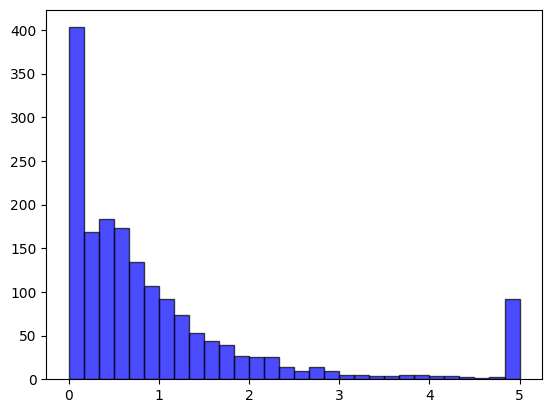

[           -inf            -inf            -inf ... 174004.52578853
 294506.56374642 697396.22786699]


notebook-cell.py: RuntimeWarning: divide by zero encountered in divide
  d = 1000/w_np


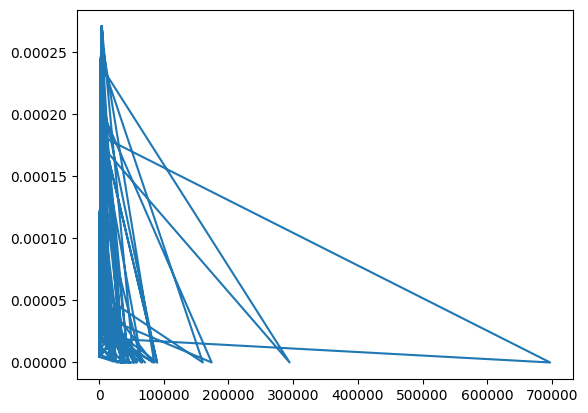

No NaN values in the filtered DataFrame.


In [4]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(data_file)

# Drop rows containing NaN values
df = df.dropna()

#print(type(df))
#print(df.head())

w = df["parallax"]
w_np = np.array(w) 
print(np.sort(w_np))
w_np = np.clip(w_np, -0.0, 5)
print(np.sort(w_np))

# Plot the histogram
plt.hist(w_np, bins='auto', alpha=0.7, color='blue', edgecolor='black')
plt.show()

d = 1000/w_np
print(np.sort(d))
L =2000
prior = (d**2/L**3)*np.exp(-d/L)
plt.plot(d, prior)
plt.show()

w = df[(df["parallax"]>-2) & (df["parallax"]<8)]

#print(pd.DataFrame.sort_values(w))

# Check if there are NaN values in the filtered DataFrame
nan_check = w.isna().any().any()

if nan_check:
    print("There are NaN values in the filtered DataFrame.")
else:
    print("No NaN values in the filtered DataFrame.")
#d = 1000.0/w_to_keep
#print(type(w))
# Convert the remaining data to NumPy arrays
data_by_column_np = {column: df[column].to_numpy() for column in df.columns}

# Print the data organized by column as NumPy arrays
#for column, array in data_by_column_np.items():
#    print(f"{column}: {array}")


The available data are:
parallax: [-1.55265614 -1.4611432  -1.44649774 ...         nan         nan
         nan]






d: [-217074.71154884 -195257.17868236 -136762.37937217  -94155.87073269
  -53674.11480179  -51217.56805443  -50280.04924544  -49592.75266301
  -47873.13550264  -44315.6433705   -43543.30704271  -42167.0719091
  -40917.19154142  -34366.92627641  -32210.1003795   -31852.8093809
  -31819.36256128  -28247.77938376  -27174.01605999  -24618.10394449]


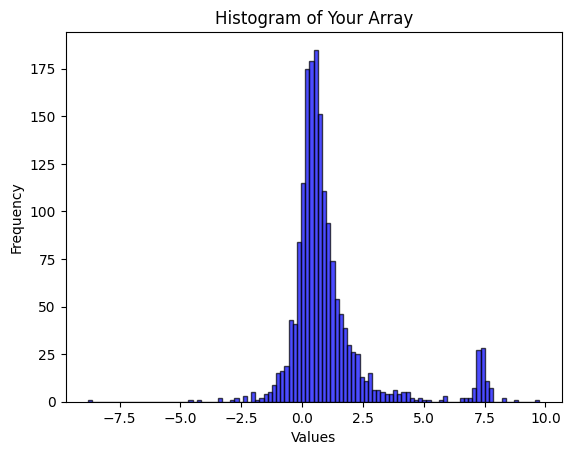

In [94]:
# Open the CSV file
with open(data_file, 'r') as file:
    # Create a CSV reader object
    csv_reader = csv.DictReader(file)

    # Initialize an empty dictionary to store data by column
    data_by_column = {column: [] for column in csv_reader.fieldnames}

    # Iterate over rows
    for row in csv_reader:
        # Update the dictionary with values from each column
        for column in csv_reader.fieldnames[1:]:
            data_by_column[column].append(row[column])

# Convert lists to NumPy arrays
#data_by_column = {column: np.array(values, dtype=float) for column, values in data_by_column.items()}

# Convert lists to NumPy arrays, handling empty strings as np.nan
#data_by_column = {
#    column: np.array([float(value) if value != '' else np.nan for value in values])
#    for column, values in data_by_column.items()}

# Print the data organized by column
print("The available data are:")
for column, values in data_by_column.items():
    observables= {
    column: np.array([float(value) if value != '' else np.nan for value in values])
    for column, values in data_by_column.items() if column != 'designation'}
    
    #print(f"{column}")

print("parallax:",np.sort(observables["parallax"])[20:])
print("\n\n\n\n\n")
#print(type(observables["parallax"]), observables["parallax"]) # unit mas= milliarcsecond
#d = 1.0/data_by_column["parallax"]
d = np.array([1000.0/float(value) if not np.isnan(value) else np.nan for value in observables["parallax"]])
#print(d)
print("d:", np.sort(d)[:20])
#print(np.min([value if not np.isnan(value) else 0 for value in d]))
# Use numpy.where to find the index
index = np.where(d == -217074.7115488448)
#print(d[1140])
#print(index)


# Delete the row from each NumPy array
data_by_column_np = {column: np.delete(array, index) for column, array in observables.items()}
d = np.array([1000.0/float(value) if not np.isnan(value) else np.nan for value in data_by_column_np["parallax"]])

#print(d[1140])
#print(np.min([value if not np.isnan(value) else 0 for value in d]))
index = np.where(d == -217074.7115488448)
#print(index)


# Plot the histogram
plt.hist(observables["parallax"], bins='auto', alpha=0.7, color='blue', edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Your Array')

# Show the plot
plt.show()

(0.0, 8.0)

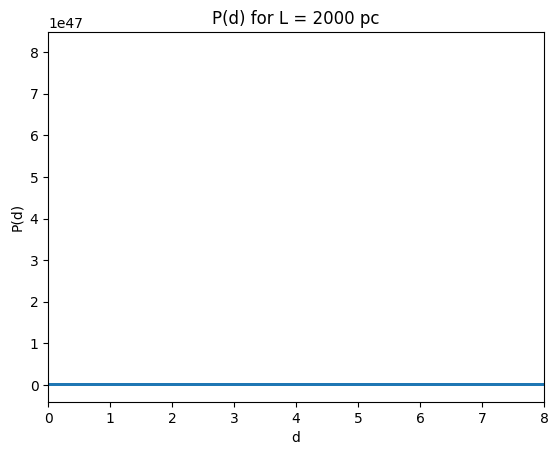

In [118]:
def likelihood(sigma, parallax, d):
    return (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*(parallax - 1/d)**2/(2*sigma**2))

def prior(d, L=2000):
    return (d**2/L**3)*np.exp(-d/L)


d = 1000/w_np
Prior =prior(d) 
plt.plot(d, Prior)
plt.xlabel("d")
plt.ylabel("P(d)")
plt.title("P(d) for L = 2000 pc")
plt.xlim([0, 8])
#plt.plot(Prior, d)


In [37]:
# test
# Your list of strings
string_list = ['0.476360354561293', '0.10135762940703638', '', '-0.26727492610283915', '', '4.146810724924782']

# Convert the strings to floats, replacing empty strings with np.nan
numeric_list = [float(value) if value != '' else np.nan for value in string_list]

# Convert the list to a NumPy array
numpy_array = np.array(numeric_list)

# Print the resulting NumPy array
print(numpy_array)

[ 0.47636035  0.10135763         nan -0.26727493         nan  4.14681072]
